In [15]:
import gymnasium as gym
import seaborn as sns
import matplotlib.pyplot as plt
import src.gymnasium_envs.convex_optimization_env
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecNormalize
from src.optimization.convex_function import ConvexFunction
from src.optimization.optimization_methods import gradient_descent_optimizer, adam_optimizer

seed = 0

At first we'll use RL optimization with learned LR

In [16]:
env = make_vec_env(
    "convex_optimization_env/ConvexOptimization-v0",
    n_envs=1,
    seed=seed,
    env_kwargs={
        "render_mode": "ansi",
        "in_features": 2
    }
)

env = VecNormalize.load("../vec_normalize_stats.pkl", env)

env.training = False
env.norm_reward = False 

model = PPO.load("../convex_optimization", env=env, seed=seed)

obs = env.reset()

x0 = env.envs[0].unwrapped.get_x_start()

In [20]:
done = False

rl_gd_info = []

while not done:
    action, _states = model.predict(obs, deterministic=True)
    
    obs, reward, terminated, info = env.step(action)
    
    rl_gd_info.append(info)

    done = terminated

Now using default gradient methods

In [18]:
function1 = ConvexFunction(in_features=2, random_state=0)

gd_info = []
adam_info = []

gradient_descent_optimizer(function1, x0=x0, opt_info=gd_info)
adam_optimizer(function1, x0=x0, opt_info=adam_info)

OptimizeResult(iteration_count=1069, x_start=array([ 0.27392337, -0.46042657]), x_best=array([0.09788781, 0.32553449]), function_value=0.4535459692964503, grad_norm=np.float64(0.30443014332280305), grad_delta_norm=np.float64(0.0010007648868914426), status=1)

Let's visualize any gradient descent

In [28]:
gd_it, gd_val = zip(*[(item['iteration'], item['function_value']) for item in gd_info])
adam_it, adam_val = zip(*[(item['iteration'], item['function_value']) for item in adam_info])
rl_gd_it, rl_gd_val = zip(*[(item[0]['iteration'], item[0]['function_value']) for item in rl_gd_info[:-2]])

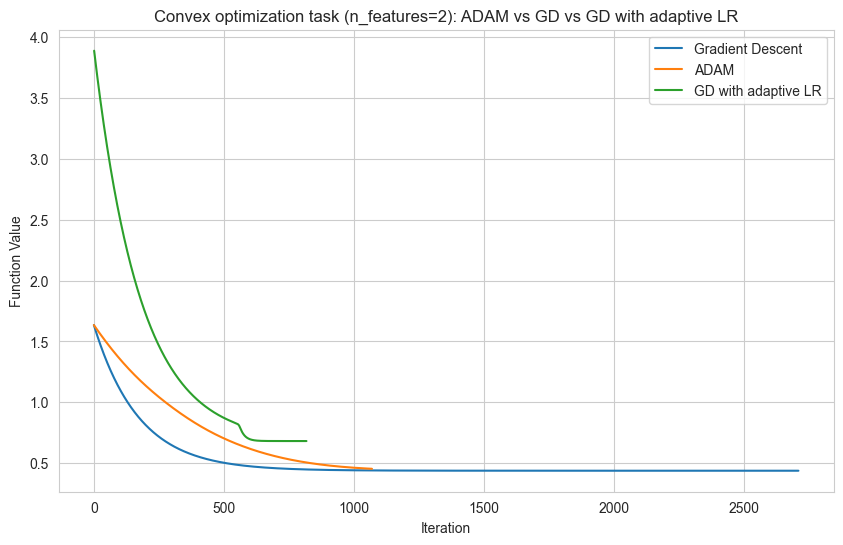

In [ ]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.lineplot(x=gd_it, y=gd_val, label='Gradient Descent')
sns.lineplot(x=adam_it, y=adam_val, label='ADAM')
sns.lineplot(x=rl_gd_it, y=rl_gd_val, label='GD with adaptive LR')

plt.title('Convex optimization task (n_features=2): ADAM vs GD vs GD with adaptive LR')
plt.xlabel('Iteration')
plt.ylabel('Function Value')
plt.legend()
plt.show()